# Find TC genesis lag KW in obs and ace2 (2001-2010, 10yr)

This is the updated code of the last section of Tropical_wave_filtering_2001_2010.ipynb, Tropical_wave_filtering_ace2_100yr.ipynb

Only summer is used (NDJFMA for SH, MJJASO for NH)

Mu-Ting Chien

2025.3.4

In [2]:
import numpy as np
from netCDF4 import Dataset
import xarray as xr
import os
import sys
sys.path.append('/barnes-engr-scratch1/c832572266/Function/')
import mjo_mean_state_diagnostics_uw as MJO
#
sys.path.append('/home/C832572266/code/function/')
import KW_diagnostics_new as KW
import matplotlib.pyplot as plt
import cartopy.util as cartopy_util
import cartopy.crs as ccrs
from datetime import datetime, timezone
from scipy.stats import binom

In [3]:
DIR                    = '/barnes-engr-scratch1/c832572266/'
file_dir_obs_ace2      = DIR + 'data_output/ace2/obs_compare_with_ace2/'
file_dir_ace2          = DIR + 'data_output/ace2/ace2_output/10yr/'
fig_dir                = DIR + 'figure/ace2_fig/kw_TC_summer_only/' # Reomte direcotry for figures 
os.makedirs(fig_dir, exist_ok=True)
expname_list  = list(['ace2','era5'])
expname2_list = list(['ace2','imerg'])

# Parameters used for KW phase composite
pi  = np.pi
dph = 1/8*np.pi
mybin = np.arange(-pi, pi+dph*2, dph)-dph/2 #play around this 1/8
phase_bin = mybin[:-1] + dph/2
PI = '\u03C0'
bin_simple = np.arange(-pi,pi+1/4*pi,1/4*pi)
y2d = 365.25

# Mutual bin for TC genesis lag KW crest
hr_bin = np.arange(-126, 126, 6)+3
hr_bin_12h = np.arange(-132, 144, 12)+6
hr_bin_daily = np.arange(-8.5, 9.5, 1)

# Load KW peak and TC genesis

In [31]:
# For each TC genesis event, find the timing of the closest KW peak at the genesis location

# Load KW phase data (same as previous code)
data          = np.load(file_dir_obs_ace2+'pr_kw-phase_ace2_2001-2010_10SN.npz')
phase_correct_10S = data['phase_correct_ace2_10S']
phase_correct_10N = data['phase_correct_ace2_10N']
time_filt     = data['time_filt']
#time_phase_ace2 = time_ace2[time_filt]
lon_ace2 = data['lon']
nlon_ace2 = np.size(lon_ace2)

data = np.load(file_dir_obs_ace2+'pr_kw-phase_imerg_2001-2010_10SN.npz')
phase_correct_imerg_10S = data['phase_correct_10S']
phase_correct_imerg_10N = data['phase_correct_10N']
time_filt_imerg     = data['time_filt']
#time_phase_imerg    = time[time_filt_imerg]
lon_imerg           = data['lon']
nlon_imerg          = np.size(lon_imerg)

# Find KW crest (the enhanced KW phase)
KW_crest_ace2_10S = np.where(phase_correct_10S==-pi/2, 1, 0)
KW_crest_imerg_10S = np.where(phase_correct_imerg_10S==-pi/2, 1, 0)
KW_crest_ace2_10N = np.where(phase_correct_10N==-pi/2, 1, 0)
KW_crest_imerg_10N = np.where(phase_correct_imerg_10N==-pi/2, 1, 0)

# Load TC data (data output is from Tropical_wave_filtering_2001_2010.ipynb)
data = np.load(file_dir_obs_ace2+'TCgenesis_associate_with_tropical_wave_phase.npz')
TC_genesis_txy_ace2 = data['TC_genesis_txy'] # code above this section sets this variable as TC_genesis_txy
it_ace2_new         = data['it']
ilat_ace2_new       = data['ilat']
ilon_ace2_new       = data['ilon']
#
data = np.load(file_dir_obs_ace2+'TCgenesis_associate_with_tropical_wave_phase_imerg-era5.npz')
TC_genesis_txy_era5 = data['TC_genesis_txy']
it_era5_new    = data['it']
ilat_era5_new  = data['ilat']
ilon_era5_new  = data['ilon']

if nlon_ace2 == nlon_imerg:
    nlon = nlon_ace2

In [41]:
# Load real time (yyyy-mm-dd-hh)

ds = xr.open_dataset(file_dir_ace2 + 'pr_kwfilt_15SN_ace2_2001-2010_2.5deg.nc')
time_ace2 = ds['time'].values

ds = xr.open_dataset(file_dir_obs_ace2 + 'pr_kwfilt_15SN_imerg_2001-2010_2.5deg.nc')
time_obs = ds['time'].values

print(time_ace2)
print(time_obs)

['2001-04-02T12:00:00.000000000' '2001-04-02T18:00:00.000000000'
 '2001-04-03T00:00:00.000000000' ... '2010-09-29T06:00:00.000000000'
 '2010-09-29T12:00:00.000000000' '2010-09-29T18:00:00.000000000']
['2001-04-02T06:00:00.000000000' '2001-04-02T12:00:00.000000000'
 '2001-04-02T18:00:00.000000000' ... '2010-10-01T00:00:00.000000000'
 '2010-10-01T06:00:00.000000000' '2010-10-01T12:00:00.000000000']


In [43]:
# Load lat (1deg*1deg)
data         = np.load(file_dir_obs_ace2+'pr_ano_15SN_imerg_2001-2010.npz')
lat_15SN_imerg = data['lat_15SN']

data          = np.load(file_dir_ace2+'pr_ano_15SN.npz')
lat_15SN_ace2 = data['lat_15SN']

In [36]:
# Find month for each time of the entire kw (phase) timeseries 
month_ace2 = time_ace2.astype('datetime64[M]').astype(int) % 12 + 1
print(month_ace2)

month_obs = time_obs.astype('datetime64[M]').astype(int) % 12 + 1
print(month_obs)

[4 4 4 ... 9 9 9]
[ 4  4  4 ... 10 10 10]


In [37]:
# Only select the KW crest that are in summer (MJJASO in NH and NDJFMA in SH)

# Transform the month array so that <6 is NH summer and >=6 is SH summer
month_ace2_tmp = month_ace2 - 5
month_ace2_tmp = np.where(month_ace2_tmp<0, month_ace2_tmp+12, month_ace2_tmp)
month_ace2_tmp = np.tile(month_ace2_tmp, (nlon, 1)).T
#
month_obs_tmp = month_obs - 5
month_obs_tmp = np.where(month_obs_tmp<0, month_obs_tmp+12, month_obs_tmp)
month_obs_tmp = np.tile(month_obs_tmp, (nlon, 1)).T

KW_crest_ace2_10S_summer  = np.where(month_ace2_tmp>=6, KW_crest_ace2_10S, 0)
KW_crest_imerg_10S_summer = np.where(month_obs_tmp>=6, KW_crest_imerg_10S, 0)
KW_crest_ace2_10N_summer  = np.where(month_ace2_tmp<6, KW_crest_ace2_10N, 0)
KW_crest_imerg_10N_summer = np.where(month_obs_tmp<6, KW_crest_imerg_10N, 0)

In [38]:
# Find the timing of the closest KW crest for each TC genesis event
for iexp in range(0,2): # ace2 or era5
    expname  = expname_list[iexp]
    expname2 = expname2_list[iexp]
    ilat     = globals()['ilat_'+expname+'_new']
    ilon     = globals()['ilon_'+expname+'_new']
    it       = globals()['it_'+expname+'_new']

    for i in range(0, np.size(ilat)): # for each TC genesis event
        if ilat[i] > 15: # NH
            KW_crest = globals()['KW_crest_'+expname2+'_10N_summer']
        else:
            KW_crest = globals()['KW_crest_'+expname2+'_10S_summer']
        KW_crest_it = np.argwhere(KW_crest[:,ilon[i]]==1).squeeze()
        if i == 0:
            dhr = np.empty([np.size(ilat)])
        if np.size(KW_crest_it)==0:
            dhr[i] = np.nan
        else:
            dt = (it[i]-KW_crest_it)*6
            dhr[i] = np.min(np.abs(dt)) # how many hours after KW crest that TC genesis occurs
            ihr = np.argwhere(np.abs(dt)==dhr[i]).squeeze()
            if np.size(ihr)>1:
                ihr = ihr[0]
            if it[i] - KW_crest_it[ihr] <0:
                dhr[i] = -dhr[i]

            if i < 2: # Print results to make sure they are reasonable 
                print('KW_crest_it:',KW_crest_it[ihr])
                print('it:',it[i])
                print('dhr:', dhr[i])
                print('-------------')
    if iexp == 0:
        dhr_ace2_10SN = dhr
    else:
        dhr_obs_10SN  = dhr

# Save output
np.savez(file_dir_obs_ace2+'TCgenesis_lag_kwcrest_hr_10SN_summer_only.npz',\
         dhr_ace2_10SN=dhr_ace2_10SN, dhr_obs_10SN=dhr_obs_10SN)

KW_crest_it: 152
it: 37
dhr: -690.0
-------------
KW_crest_it: 54
it: 69
dhr: 90.0
-------------
KW_crest_it: 25
it: 6
dhr: -114.0
-------------
KW_crest_it: 3
it: 6
dhr: 18.0
-------------


# Plot statistics of TC genesis lag KW crest (hours)


In [39]:
# Define KW phase for NH average and SH average separately (KW filtered precip is meridionally averaged within NH or SH first)
#            Only consider the lag day of the nearest KW to cyclogenesis event
data = np.load(file_dir_obs_ace2+'TCgenesis_lag_kwcrest_hr_10SN_summer_only.npz')
dhr_ace2_10SN = data['dhr_ace2_10SN']
dhr_obs_10SN  = data['dhr_obs_10SN']

# TC genesis lags KW days in each basin

In [6]:
# Load basin info
basin_list    = list(['NI','NWPAC','NEPAC','NATL','SI','SPAC'])
basin_long_list = list(['North IO','North WestPac','North EastPac','North Atl','South IO','South Pac'])
basin_lon_min = np.array([45, 105, 180, 265, 35, 135])
basin_lon_max = np.array([105, 180, 265, 357.5, 135, 270])
latmax = 30 #25 is not used, use 30
basin_lat_min = np.array([0,    0,    0,  0,  -latmax, -latmax])
basin_lat_max = np.array([latmax,  latmax, latmax, latmax,    0, 0])
nbasin        = np.size(basin_list)

In [46]:
# Load TC genesis data and find the basin for each event
fname_list = list(['','_imerg-era5'])

for iexp in range(0, 2):

    expname        = expname_list[iexp]
    filename       = 'TCgenesis_associate_with_tropical_wave_phase'
    data           = np.load(file_dir_obs_ace2 + filename + fname_list[iexp]+'.npz')
    TC_genesis_txy = data['TC_genesis_txy']
    ilat           = data['ilat']
    ilon           = data['ilon']
    it             = data['it']
    basin_idx      = np.zeros(np.size(it))
    basin_idx[:]   = np.nan

    if iexp == 0:
        lat_tmp = lat_15SN_ace2
        lon_tmp = lon_ace2
    else:
        lat_tmp = lat_15SN_imerg
        lon_tmp = lon_imerg

    # Find which basin does each TC genesis event falls into
    for i in range(0, np.size(ilat)): # for each TC genesis event
        for ibasin in range(0, nbasin):
            ilat_int = int(ilat[i])
            ilon_int = int(ilon[i])
            dlatmin = lat_tmp[ilat_int]-basin_lat_min[ibasin]
            dlatmax = lat_tmp[ilat_int]-basin_lat_max[ibasin]
            dlonmin = lon_tmp[ilon_int]-basin_lon_min[ibasin]
            dlonmax = lon_tmp[ilon_int]-basin_lon_max[ibasin]
            #print(dlatmin, dlatmax)
            #print(dlonmin, dlonmax)
            if dlatmin*dlatmax<0 and dlonmin*dlonmax<0:
                basin_idx[i] = ibasin
                #print(lat_15SN_ace2[ilat_int], lon_ace2[ilon_int], basin_list[ int(basin_idx[i])])
                continue

    # Save basn index to original input file
    np.savez(file_dir_obs_ace2 + filename + fname_list[iexp]+'.npz',\
            TC_genesis_txy=TC_genesis_txy, it =it, ilat=ilat, ilon=ilon,\
                basin_idx = basin_idx)

In [47]:
# Load TC genesis lag KW time data, and separate by basin

# Load dhr 
data0 = np.load(file_dir_obs_ace2+'TCgenesis_lag_kwcrest_hr_10SN_summer_only.npz')

for iexp in range(0, 2):
    
    # Load TC genesis data
    filename       = 'TCgenesis_associate_with_tropical_wave_phase'
    data           = np.load(file_dir_obs_ace2 + filename + fname_list[iexp]+'.npz')
    basin_idx      = data['basin_idx']
    print(np.size(basin_idx))

    if iexp == 0:
        dhr = data0['dhr_ace2_10SN']
    else:
        dhr = data0['dhr_obs_10SN']

    dhr_basin0 = np.where(basin_idx==0, dhr,  np.nan)
    dhr_basin0 = dhr_basin0[np.isnan(dhr_basin0)==0]
    #
    dhr_basin1 = np.where(basin_idx==1, dhr,  np.nan)
    dhr_basin1 = dhr_basin1[np.isnan(dhr_basin1)==0]
    #
    dhr_basin2 = np.where(basin_idx==2, dhr,  np.nan)
    dhr_basin2 = dhr_basin2[np.isnan(dhr_basin2)==0]
    #
    dhr_basin3 = np.where(basin_idx==3, dhr,  np.nan)
    dhr_basin3 = dhr_basin3[np.isnan(dhr_basin3)==0]
    #
    dhr_basin4 = np.where(basin_idx==4, dhr,  np.nan)
    dhr_basin4 = dhr_basin4[np.isnan(dhr_basin4)==0]
    #
    dhr_basin5 = np.where(basin_idx==5, dhr,  np.nan)
    dhr_basin5 = dhr_basin5[np.isnan(dhr_basin5)==0]

    test = 1
    if test == 1:
        # Test only
        print(np.size(dhr_basin0))
        print(np.size(dhr_basin1))
        print(np.size(dhr_basin2))
        print(np.size(dhr_basin3))
        print(np.size(dhr_basin4))
        print(np.size(dhr_basin5))
    print('---------------')
    
    # Save output
    np.savez(file_dir_obs_ace2+'TCgenesis_lag_kwcrest_hr_10SN_'+expname_list[iexp]+'_basin_summer_only.npz',\
            dhr_basin0=dhr_basin0, dhr_basin1=dhr_basin1,\
            dhr_basin2=dhr_basin2, dhr_basin3=dhr_basin3,\
            dhr_basin4=dhr_basin4, dhr_basin5=dhr_basin5,\
            basin_list=basin_list)

483
16
174
68
72
83
70
---------------
538
25
186
71
70
126
58
---------------


# Plot TC genesis lag KW days (dhr) for each basin

In [4]:
# Load dhr for ace2 and era5
data            = np.load(file_dir_obs_ace2+'TCgenesis_lag_kwcrest_hr_10SN_'+expname_list[0]+'_basin_summer_only.npz')
dhr_ace2_basin0 = data['dhr_basin0']
dhr_ace2_basin1 = data['dhr_basin1']
dhr_ace2_basin2 = data['dhr_basin2']
dhr_ace2_basin3 = data['dhr_basin3']
dhr_ace2_basin4 = data['dhr_basin4']
dhr_ace2_basin5 = data['dhr_basin5']

data            = np.load(file_dir_obs_ace2+'TCgenesis_lag_kwcrest_hr_10SN_'+expname_list[1]+'_basin_summer_only.npz')
dhr_era5_basin0 = data['dhr_basin0']
dhr_era5_basin1 = data['dhr_basin1']
dhr_era5_basin2 = data['dhr_basin2']
dhr_era5_basin3 = data['dhr_basin3']
dhr_era5_basin4 = data['dhr_basin4']
dhr_era5_basin5 = data['dhr_basin5']

In [7]:
# Statistical test for each basin

for ibasin in range(0, nbasin):
    print('------------')
    print(basin_list[ibasin])
    dhr_ace2_tmp = globals()['dhr_ace2_basin'+str(ibasin)]
    dhr_era5_tmp = globals()['dhr_era5_basin'+str(ibasin)]
    
    n_ace2_basin = np.sum(np.abs(dhr_ace2_tmp)<=8.5*24)
    n_obs_basin  = np.sum(np.abs(dhr_era5_tmp)<=8.5*24)
    print(np.size(dhr_ace2_tmp), n_ace2_basin)
    print(n_ace2_basin, n_obs_basin)
    p = 1/(np.size(hr_bin_daily)-1)
    p_6hr = 1/(np.size(hr_bin)-1)
    p_12hr = 1/(np.size(hr_bin_12h)-1)    

    # Find 99.9 percentile
    target_cdf = 0.999
    target_cdf_min = 0.005
    target_cdf_6h = 0.999
    target_cdf_12h = 0.99

    if ibasin == 0:
        x_99_ace2_basin = np.empty([nbasin])
        x_99_obs_basin = np.empty([nbasin])
        x_99_ace2_6hr_basin = np.empty([nbasin])
        x_99_obs_6hr_basin = np.empty([nbasin])
        #
        x_99_ace2_12hr_basin = np.empty([nbasin])
        x_99_obs_12hr_basin = np.empty([nbasin])

    x_99_ace2_basin[ibasin] = binom.ppf(target_cdf, n_ace2_basin, p)
    x_99_obs_basin[ibasin]  = binom.ppf(target_cdf, n_obs_basin, p)
    x_99_ace2_6hr_basin[ibasin] = binom.ppf(target_cdf_6h, n_ace2_basin, p_6hr)
    x_99_obs_6hr_basin[ibasin]  = binom.ppf(target_cdf_6h, n_obs_basin, p_6hr)
    #
    x_99_ace2_12hr_basin[ibasin] = binom.ppf(target_cdf_12h, n_ace2_basin, p_12hr)
    x_99_obs_12hr_basin[ibasin]  = binom.ppf(target_cdf_12h, n_obs_basin, p_12hr)


    print(x_99_ace2_basin[ibasin], x_99_obs_basin[ibasin])
    print(x_99_ace2_6hr_basin[ibasin], x_99_obs_6hr_basin[ibasin])

------------
NI
16 9
9 16
4.0 5.0
3.0 3.0
------------
NWPAC
174 140
140 155
18.0 19.0
10.0 11.0
------------
NEPAC
68 66
66 65
11.0 11.0
7.0 7.0
------------
NATL
72 62
62 57
10.0 10.0
6.0 6.0
------------
SI
83 73
73 121
12.0 16.0
7.0 9.0
------------
SPAC
70 61
61 58
10.0 10.0
6.0 6.0


In [11]:
# Save significance level
np.savez(file_dir_obs_ace2+'TCgenesis_lag_kwcrest_99.9_significance_level.npz', \
         x_99_ace2_daily_basin = x_99_ace2_basin,\
         x_99_ace2_6hr_basin = x_99_ace2_6hr_basin,\
         x_99_ace2_12hr_basin = x_99_ace2_12hr_basin,\
         x_99_obs_daily_basin = x_99_obs_basin,\
         x_99_obs_6hr_basin = x_99_obs_6hr_basin,\
         x_99_obs_12hr_basin = x_99_obs_12hr_basin)

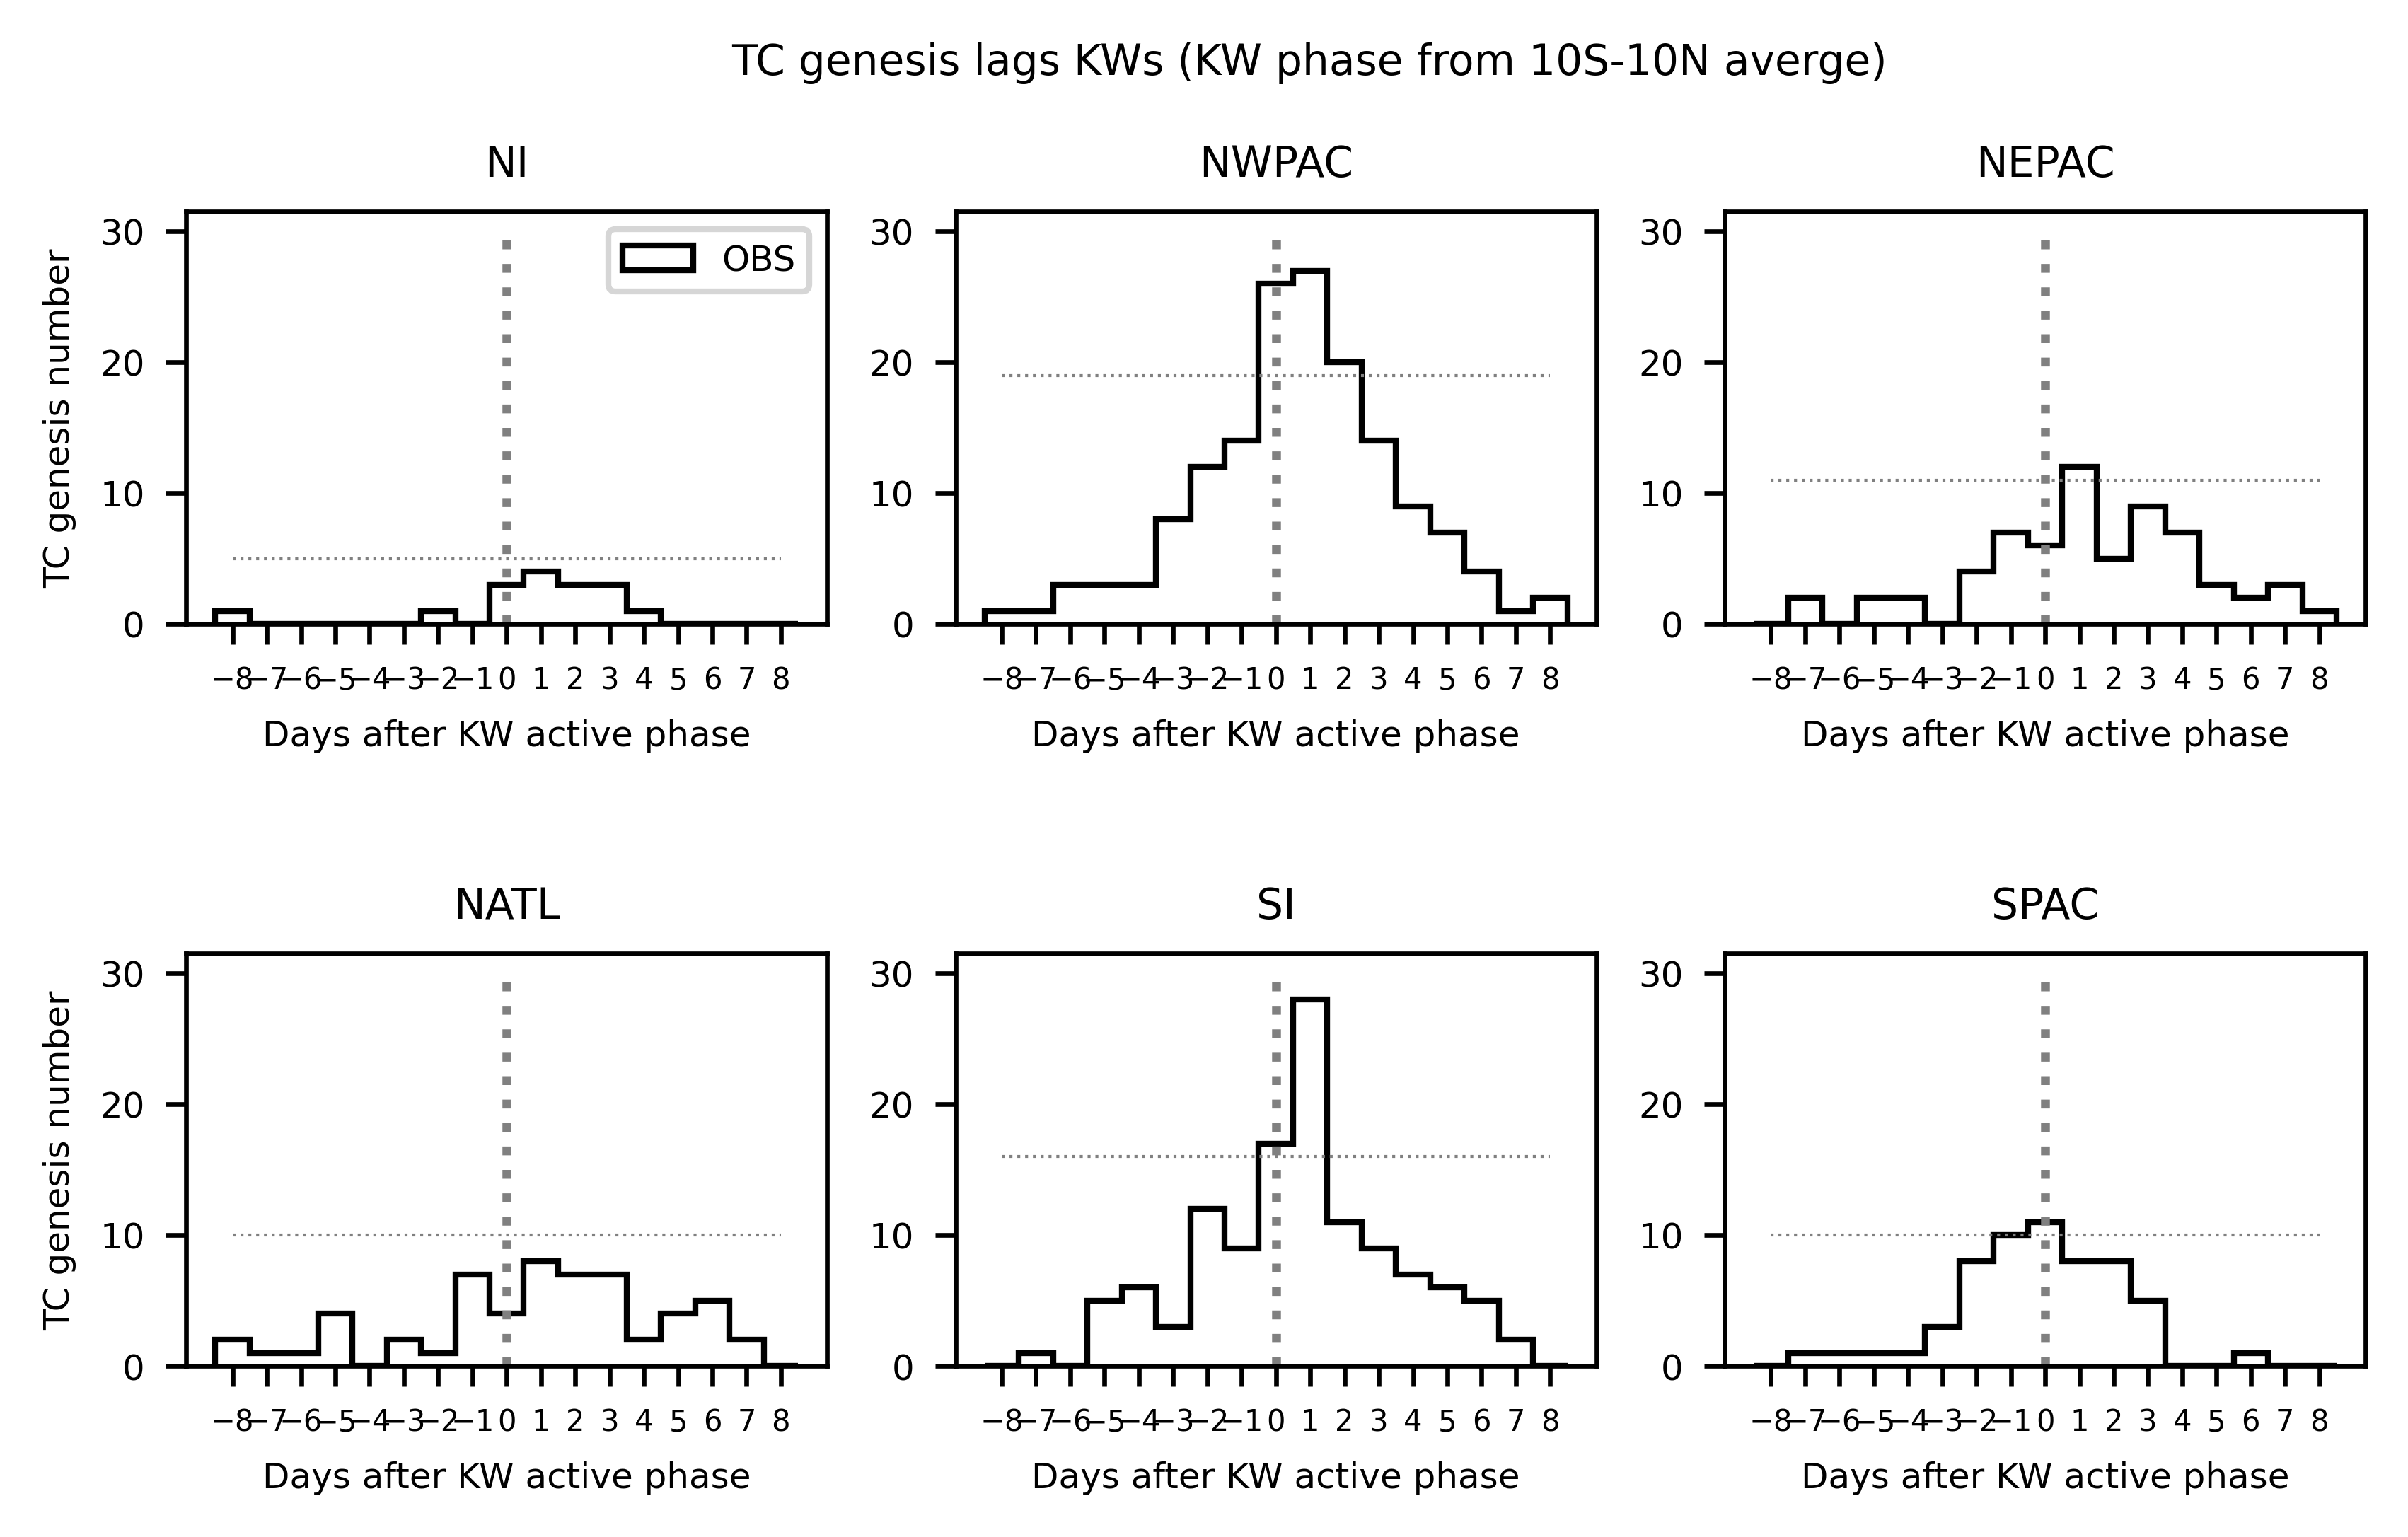

In [9]:
# Plot TC genesis for each basin
obs_only = 1 #0 or 1
ace2_only = 0 # 0 or 1
obs_only_list = list(['','_only_obs'])
ace2_only_list = list(['','_only_ace2'])
hr_bin_6h_12h = 1 # or 0 (0: 6h, 1: 12h)
hr_list = list(['','_12h'])
for bin_daily in range(1,2): # only plot daily
    if bin_daily == 0:
        fig_name = 'KW_TCgenesis_laghr_histogram_10SN_each_basin'+obs_only_list[obs_only]+ace2_only_list[ace2_only]+hr_list[hr_bin_6h_12h]+'.png'
    else:
        fig_name = 'KW_TCgenesis_laghr_histogram_10SN_daily_each_basin'+obs_only_list[obs_only]+ace2_only_list[ace2_only]+'.png'
    fig = plt.subplots(2,3,figsize=(6.5, 4),dpi=600)
    plt.subplots_adjust(left=0.2,right=0.99,top=0.88,bottom=0.2, hspace=0.8, wspace=0.2)
    plt.rcParams.update({'font.size': 6})
    zero = np.array([0,0])
    for ibasin in range(0, nbasin):
        plt.subplot(2, 3, ibasin+1)
        dhr_tmp_ace2 = globals()['dhr_ace2_basin'+str(ibasin)]
        dhr_tmp_era5 = globals()['dhr_era5_basin'+str(ibasin)]
        if bin_daily == 0:
            if obs_only == 0:
                if hr_bin_6h_12h == 0:
                    plt.hist(dhr_tmp_ace2, hr_bin, color='b',histtype='step')
                    plt.plot([-117,117], [x_99_ace2_6hr_basin[ibasin], x_99_ace2_6hr_basin[ibasin]], color='dodgerblue', linewidth=0.5, linestyle='dashed')
                else:
                    plt.hist(dhr_tmp_ace2, hr_bin_12h, color='b',histtype='step')
                    plt.plot([-117,117], [x_99_ace2_12hr_basin[ibasin], x_99_ace2_12hr_basin[ibasin]], color='dodgerblue', linewidth=0.5, linestyle='dashed')
            if ace2_only == 0:
                if hr_bin_6h_12h == 0:
                    plt.hist(dhr_tmp_era5, hr_bin, color='k',label=':',histtype='step')
                    plt.plot([-117,117], [x_99_obs_6hr_basin[ibasin], x_99_obs_6hr_basin[ibasin]], color='grey', linewidth=0.5, linestyle=':')
                else:
                    plt.hist(dhr_tmp_era5, hr_bin_12h, color='k',label=':',histtype='step')
                    plt.plot([-117,117], [x_99_obs_12hr_basin[ibasin], x_99_obs_12hr_basin[ibasin]], color='grey', linewidth=0.5, linestyle=':')
                #plt.hist(dhr_tmp_era5, hr_bin_12h, color='k',label=':',histtype='step')
                
            plt.xlabel('Hours after KW active phase')
            plt.xticks(np.arange(-120,144,24), fontsize=5)
            plt.plot(zero, [0,11], color='grey',linestyle=':')
        else:
            if obs_only == 0:
                plt.hist(dhr_tmp_ace2/24, hr_bin_daily, color='b',histtype='step')
                plt.plot([-8,8], [x_99_ace2_basin[ibasin], x_99_ace2_basin[ibasin]], color='dodgerblue', linewidth=0.5, linestyle='dashed')
            if ace2_only == 0:
                plt.hist(dhr_tmp_era5/24, hr_bin_daily, color='k',label=':',histtype='step') 
                plt.plot([-8,8], [x_99_obs_basin[ibasin], x_99_obs_basin[ibasin]], color='grey', linewidth=0.5, linestyle=':')
            plt.xlabel('Days after KW active phase')
            plt.xticks(np.arange(-8,9,1), fontsize=5)
            #plt.xticks(np.arange(-5,6,1), fontsize=5.5)
            plt.plot(zero, [0,30], color='grey',linestyle=':')
        if ibasin == 0:
            if obs_only == 1:
                plt.legend(['OBS'])
            if ace2_only == 1:
                plt.legend(['ACE2-ERA5'])
            if obs_only == 0 and ace2_only == 0:
                plt.legend(['ACE2-ERA5','OBS'])
        if ibasin == 0 or ibasin == 3:
            plt.ylabel('TC genesis number')
        plt.title(basin_list[ibasin])
    plt.suptitle('                                            TC genesis lags KWs (KW phase from 10S-10N averge)')
    plt.savefig(fig_dir+fig_name,format='png', dpi=600)
    plt.show()
    plt.close()